# 02. FP32 CLRKDNet ONNX Lane Output Sanity Check

이번 노트북의 질문은 속도가 아니라 **모델이 실제로 lane output을 그럴듯하게 내는가**임.

03번 이후의 camera/preprocess, latency, quantization 실험은 모두 이 기준점이 있어야 의미가 있다.

검증 흐름:

```text
이미지 1장 준비
-> FP32 ONNX forward
-> CLRKDNet output decode
-> lane center / confidence / lane count 확인
-> overlay image 저장
```

주의: 이 노트북은 CULane mAP 같은 정식 정확도 평가가 아님. 먼저 모델 변환/후처리/시각화가 정상적으로 연결되는지 보는 sanity check임.

In [1]:
from pathlib import Path
import sys
import time
import importlib.util

import cv2
import numpy as np
import onnxruntime as ort
from PIL import Image as PILImage
from IPython.display import display, Image, Markdown

ROOT = Path('/home/pi/AI_CAR/architecture_validation/lane_model')
SCRIPTS = ROOT / 'scripts'
MODELS = ROOT / 'models'
OUTPUTS = ROOT / 'outputs'
SANITY_DIR = OUTPUTS / 'lane_output_sanity'
SANITY_DIR.mkdir(parents=True, exist_ok=True)

MODEL = MODELS / 'clrkdnet_resnet18_culane.onnx'
LANE_TRACER = SCRIPTS / '07_lane_tracer_onnx_drive.py'

spec = importlib.util.spec_from_file_location('lane_tracer', LANE_TRACER)
lane_tracer = importlib.util.module_from_spec(spec)
# Python 3.13 dataclass import needs the module registered before exec_module.
sys.modules['lane_tracer'] = lane_tracer
spec.loader.exec_module(lane_tracer)

print('root:', ROOT)
print('model:', MODEL, MODEL.exists())
print('lane_tracer helper:', LANE_TRACER, LANE_TRACER.exists())
print('outputs:', SANITY_DIR)

root: /home/pi/AI_CAR/architecture_validation/lane_model
model: /home/pi/AI_CAR/architecture_validation/lane_model/models/clrkdnet_resnet18_culane.onnx True
lane_tracer helper: /home/pi/AI_CAR/architecture_validation/lane_model/scripts/07_lane_tracer_onnx_drive.py True
outputs: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity


2026-04-17 04:18:47.196118269 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card1": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"
2026-04-17 04:18:47.196166121 [W:onnxruntime:Default, device_discovery.cc:283 GetGpuDevices] Failed to detect devices under "/sys/class/drm/card0": device_discovery.cc:93 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


## 1. 입력 이미지 선택

기본값은 03번 카메라 전처리 검증에서 저장한 color-fixed 원본 프레임이다.

이 이미지는 책상 위 임시 배치라 CULane 도메인과 다르다. 따라서 `no_lane`이 나와도 모델 실패로 단정하지 않는다.

내일 map 이미지나 CULane raw sample 이미지를 가져오면 `IMAGE_PATH`만 바꿔서 같은 검증을 다시 하면 된다.

IMAGE_PATH: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/02_raw_camera_frame_color_fixed.jpg


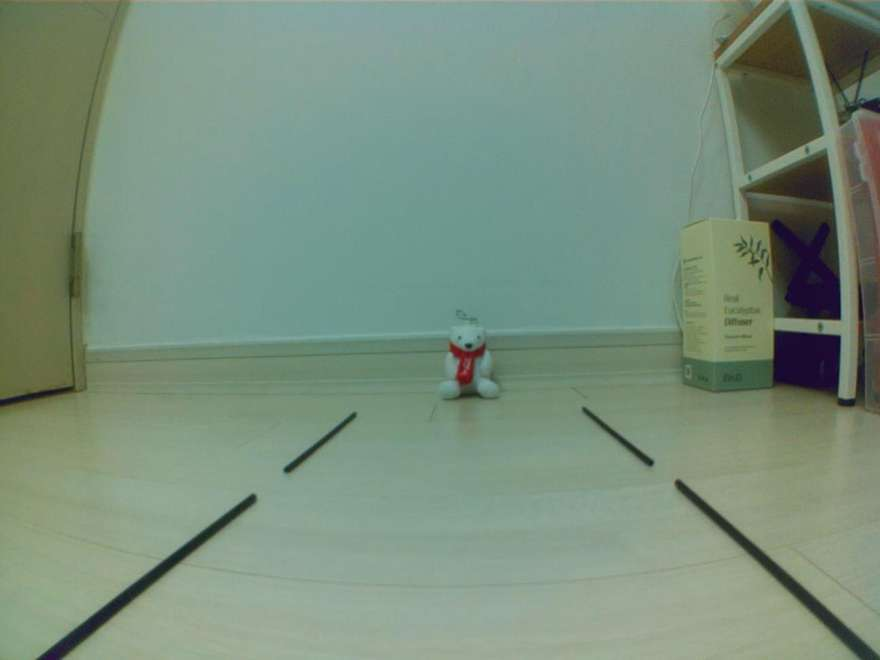

In [2]:
IMAGE_PATH = OUTPUTS / '02_raw_camera_frame_color_fixed.jpg'

fallbacks = [
    OUTPUTS / '02_raw_camera_frame_color_fixed.jpg',
    OUTPUTS / '02_raw_camera_frame.jpg',
    OUTPUTS / 'camera_preprocess_preview.jpg',
]

if not IMAGE_PATH.exists():
    for path in fallbacks:
        if path.exists():
            IMAGE_PATH = path
            break

assert IMAGE_PATH.exists(), f'입력 이미지가 없음. 먼저 03 camera notebook에서 이미지를 저장하거나 IMAGE_PATH를 수정해야 함: {IMAGE_PATH}'
print('IMAGE_PATH:', IMAGE_PATH)
display(Image(filename=str(IMAGE_PATH), width=720))

## 2. FP32 ONNX forward + lane decode

아래 셀은 기존 `07_lane_tracer_onnx_drive.py`의 전처리/후처리 함수를 그대로 사용한다.

따라서 여기서 나온 `center_x`, `confidence`, `lane_count`는 나중에 lane-only 주행 스크립트에서 사용할 값과 같은 기준이다.

In [3]:
THREADS = 4
INPUT_WIDTH = 800
INPUT_HEIGHT = 320
CONF_THRESHOLD = 0.4
LOOKAHEAD_Y = 0.75
MAX_LANES = 4
DEFAULT_LANE_WIDTH = 0.38

options = ort.SessionOptions()
options.intra_op_num_threads = THREADS
options.inter_op_num_threads = 1
session = ort.InferenceSession(str(MODEL), sess_options=options, providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name
output_names = [item.name for item in session.get_outputs()]

print('input:', input_name, session.get_inputs()[0].shape, session.get_inputs()[0].type)
print('outputs:', output_names)

input: image ['batch', 3, 320, 800] tensor(float)
outputs: ['raw_predictions']


crop_top: 445
tensor_shape: (1, 3, 320, 800)
output_shape: (1, 192, 78)
single_forward_ms: 258.53
center_x: None
offset: 0.0
confidence: 0.0
left_x: None
right_x: None
lane_count: 0
reason: no_lane
lane_samples: []
motor_command_dry_run: MotorCommand(left=0.0, right=0.0, reason='no_lane')
preprocess_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/02_fp32_lane_input_800x320.jpg
overlay_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/02_fp32_lane_output_overlay.jpg


**Model input preview 800x320**

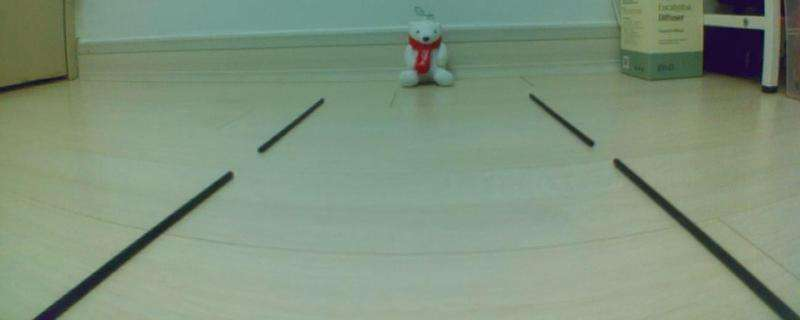

**FP32 lane output overlay**

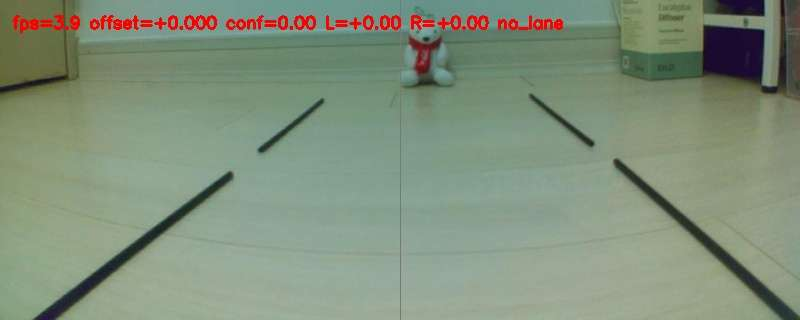

In [4]:
frame_rgb = np.array(PILImage.open(IMAGE_PATH).convert('RGB'))

tensor, resized_rgb, crop_top = lane_tracer.preprocess_frame(
    frame_rgb,
    input_width=INPUT_WIDTH,
    input_height=INPUT_HEIGHT,
    crop_top=None,
    divide_255=True,
)

start = time.perf_counter()
output = session.run(output_names, {input_name: tensor})[0]
elapsed_ms = (time.perf_counter() - start) * 1000.0

estimate, previous_lane_width, lane_samples = lane_tracer.decode_lane_estimate(
    output,
    conf_threshold=CONF_THRESHOLD,
    lookahead_y=LOOKAHEAD_Y,
    max_lanes=MAX_LANES,
    default_lane_width=DEFAULT_LANE_WIDTH,
    previous_lane_width=None,
)
command = lane_tracer.decide_motor_command(
    estimate,
    base_speed=0.24,
    min_speed=0.16,
    lost_speed=0.0,
    steer_gain=0.75,
    max_turn=0.16,
    steer_sign=1.0,
    max_offset_for_speed=0.22,
)

debug_bgr = lane_tracer.draw_debug(resized_rgb, estimate, command, lane_samples, fps=1000.0 / max(elapsed_ms, 1e-6))
overlay_path = SANITY_DIR / '02_fp32_lane_output_overlay.jpg'
preprocess_path = SANITY_DIR / '02_fp32_lane_input_800x320.jpg'
cv2.imwrite(str(overlay_path), debug_bgr)
PILImage.fromarray(resized_rgb).save(preprocess_path)

print('crop_top:', crop_top)
print('tensor_shape:', tensor.shape)
print('output_shape:', output.shape)
print('single_forward_ms:', round(elapsed_ms, 2))
print('center_x:', None if estimate.center_x is None else round(estimate.center_x, 4))
print('offset:', round(estimate.offset, 4))
print('confidence:', round(estimate.confidence, 4))
print('left_x:', None if estimate.left_x is None else round(estimate.left_x, 4))
print('right_x:', None if estimate.right_x is None else round(estimate.right_x, 4))
print('lane_count:', estimate.lane_count)
print('reason:', estimate.reason)
print('lane_samples:', lane_samples)
print('motor_command_dry_run:', command)
print('preprocess_path:', preprocess_path)
print('overlay_path:', overlay_path)

display(Markdown('**Model input preview 800x320**'))
display(Image(filename=str(preprocess_path), width=720))
display(Markdown('**FP32 lane output overlay**'))
display(Image(filename=str(overlay_path), width=720))

## 3. 내가 받은 driver_37_30frame subset sanity

아래 셀은 사용자가 직접 받은 CULane `driver_37_30frame` 데이터에서 뽑은 subset을 기준으로 돌린다.

원본 위치:

```text
~\03_Data\CULane
```

Pi에는 전체 3357장을 모두 올리지 않고, 먼저 아래처럼 100장 subset만 올려둔 상태다.

```text
/home/pi/AI_CAR/architecture_validation/lane_model/inputs/culane_driver37_subset
```

구성:

```text
non-empty label 80장
empty label 20장
총 100장
```

이 셀은 정식 CULane F1 평가가 아니라, **FP32 ONNX + 현재 rough decode가 실제 CULane raw frame에서 lane center를 내는지 확인하는 sanity check**다.

sample_count_for_display: 8
{'file': 'driver_37_30frame/driver_37_30frame/05181432_0203.MP4/00000.jpg', 'forward_ms': 278.9, 'center_x': None, 'confidence': 0.0, 'lane_count': 0, 'reason': 'no_lane', 'overlay': PosixPath('/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_interactive/01_00000_overlay.jpg')}
{'file': 'driver_37_30frame/driver_37_30frame/05181432_0203.MP4/01290.jpg', 'forward_ms': 256.76, 'center_x': 0.6358, 'confidence': 0.7565, 'lane_count': 3, 'reason': 'both_lanes', 'overlay': PosixPath('/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_interactive/02_01290_overlay.jpg')}
{'file': 'driver_37_30frame/driver_37_30frame/05181432_0203.MP4/02040.jpg', 'forward_ms': 252.51, 'center_x': 0.3605, 'confidence': 0.7313, 'lane_count': 2, 'reason': 'both_lanes', 'overlay': PosixPath('/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_interactive/03_020

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/00000.jpg / reason=no_lane / conf=0.0 / center=None**

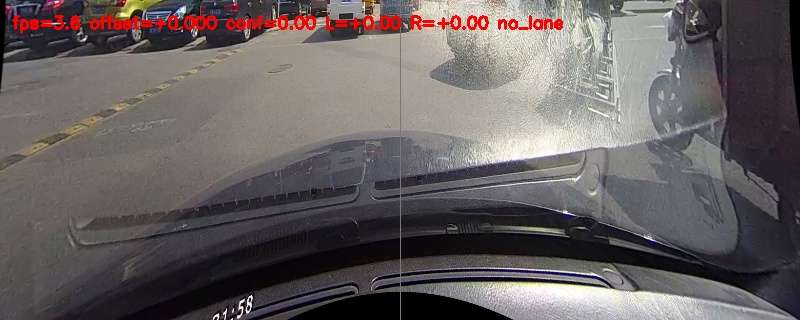

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/01290.jpg / reason=both_lanes / conf=0.7565 / center=0.6358**

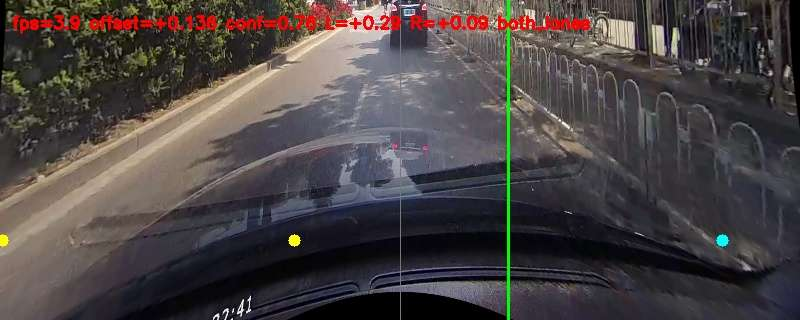

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/02040.jpg / reason=both_lanes / conf=0.7313 / center=0.3605**

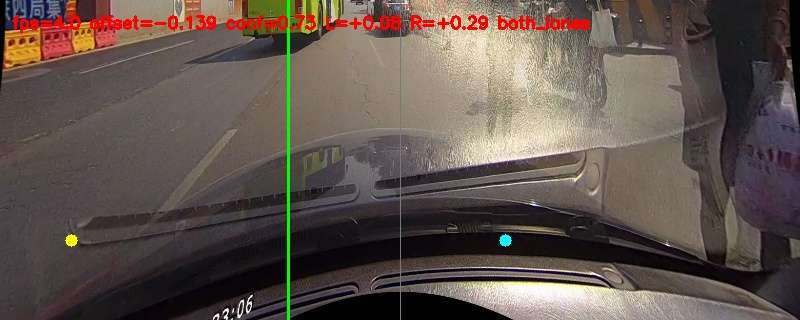

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/03240.jpg / reason=both_lanes / conf=0.5295 / center=0.7277**

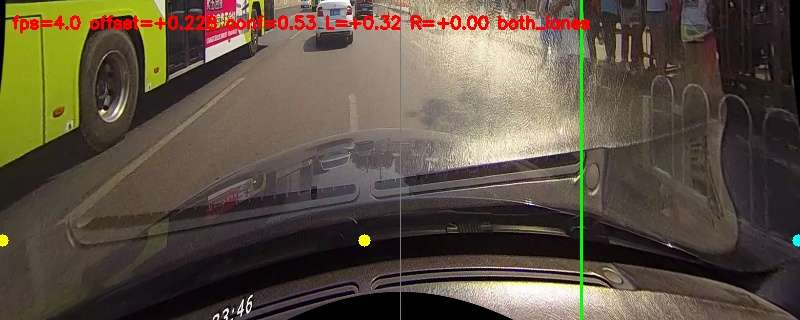

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/03420.jpg / reason=both_lanes / conf=0.7831 / center=0.6289**

**driver_37_30frame/driver_37_30frame/05181432_0203.MP4/04560.jpg / reason=both_lanes / conf=0.544 / center=0.6826**

**driver_37_30frame/driver_37_30frame/05181520_0219.MP4/00510.jpg / reason=both_lanes / conf=0.7869 / center=0.7362**

**driver_37_30frame/driver_37_30frame/05181520_0219.MP4/00660.jpg / reason=both_lanes / conf=0.7766 / center=0.7367**

In [5]:
DRIVER37_SUBSET_DIR = ROOT / 'inputs' / 'culane_driver37_subset'
DRIVER37_OUT = SANITY_DIR / 'driver37_subset_interactive'
DRIVER37_OUT.mkdir(parents=True, exist_ok=True)

# 먼저 몇 장만 노트북에서 직접 확인한다.
sample_paths = sorted(list(DRIVER37_SUBSET_DIR.rglob('*.jpg')))[:8]
print('sample_count_for_display:', len(sample_paths))
assert sample_paths, f'no driver37 subset images: {DRIVER37_SUBSET_DIR}'

rows = []
for idx, path in enumerate(sample_paths, start=1):
    frame_rgb = np.array(PILImage.open(path).convert('RGB'))
    tensor, resized_rgb, crop_top = lane_tracer.preprocess_frame(
        frame_rgb,
        input_width=INPUT_WIDTH,
        input_height=INPUT_HEIGHT,
        crop_top=None,
        divide_255=True,
    )
    start = time.perf_counter()
    output = session.run(output_names, {input_name: tensor})[0]
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    estimate, _, lane_samples = lane_tracer.decode_lane_estimate(
        output,
        conf_threshold=CONF_THRESHOLD,
        lookahead_y=LOOKAHEAD_Y,
        max_lanes=MAX_LANES,
        default_lane_width=DEFAULT_LANE_WIDTH,
        previous_lane_width=None,
    )
    command = lane_tracer.decide_motor_command(
        estimate,
        base_speed=0.24,
        min_speed=0.16,
        lost_speed=0.0,
        steer_gain=0.75,
        max_turn=0.16,
        steer_sign=1.0,
        max_offset_for_speed=0.22,
    )
    debug_bgr = lane_tracer.draw_debug(resized_rgb, estimate, command, lane_samples, fps=1000.0 / max(elapsed_ms, 1e-6))
    rel = path.relative_to(DRIVER37_SUBSET_DIR).as_posix()
    out_path = DRIVER37_OUT / f'{idx:02d}_{path.stem}_overlay.jpg'
    cv2.imwrite(str(out_path), debug_bgr)
    rows.append({
        'file': rel,
        'forward_ms': round(elapsed_ms, 2),
        'center_x': None if estimate.center_x is None else round(estimate.center_x, 4),
        'confidence': round(estimate.confidence, 4),
        'lane_count': estimate.lane_count,
        'reason': estimate.reason,
        'overlay': out_path,
    })

for row in rows:
    print(row)

for row in rows[:8]:
    display(Markdown(f"**{row['file']} / reason={row['reason']} / conf={row['confidence']} / center={row['center_x']}**"))
    display(Image(filename=str(row['overlay']), width=720))

## 4. driver_37_30frame 100장 batch 결과

아래 결과는 같은 subset 100장을 Pi에서 별도 batch script로 돌린 결과다.

실행 스크립트:

```text
/home/pi/AI_CAR/architecture_validation/lane_model/scripts/02_lane_output_sanity_batch.py
```

결과 폴더:

```text
/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval
```

이 결과는 블로그 figure로 쓰기 위한 요약값이다.

summary_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval/summary.json
{
  "images": 100,
  "label_nonempty": 80,
  "label_empty": 20,
  "pred_detected": 79,
  "pred_detected_rate": 0.79,
  "gt_center_available": 80,
  "gt_center_detected": 78,
  "gt_center_detected_rate": 0.975,
  "empty_false_positive": 1,
  "empty_false_positive_rate": 0.05,
  "mean_abs_center_error": 0.04734252564102564,
  "median_abs_center_error": 0.018043,
  "mean_forward_ms": 283.4165907599936,
  "fps_from_mean_forward": 3.5283749526393553,
  "reason_counts": {
    "no_lane": 20,
    "both_lanes": 70,
    "left_only": 7,
    "right_only": 2,
    "no_valid_lane": 1
  }
}
/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval/reason_counts.png


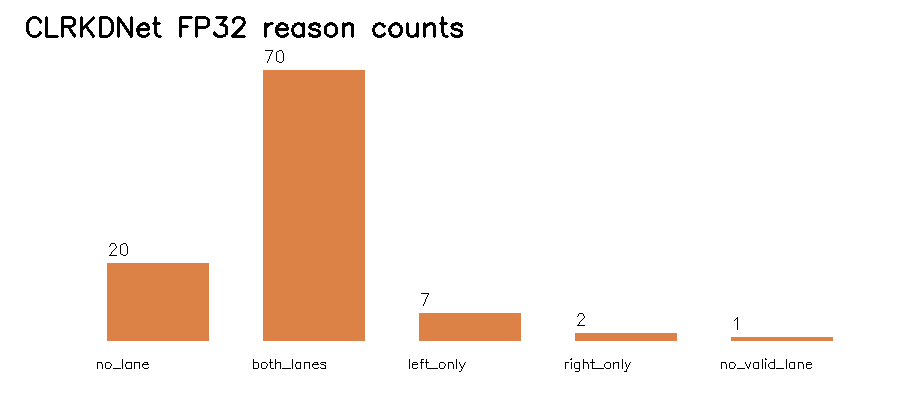

/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval/confidence_hist.png


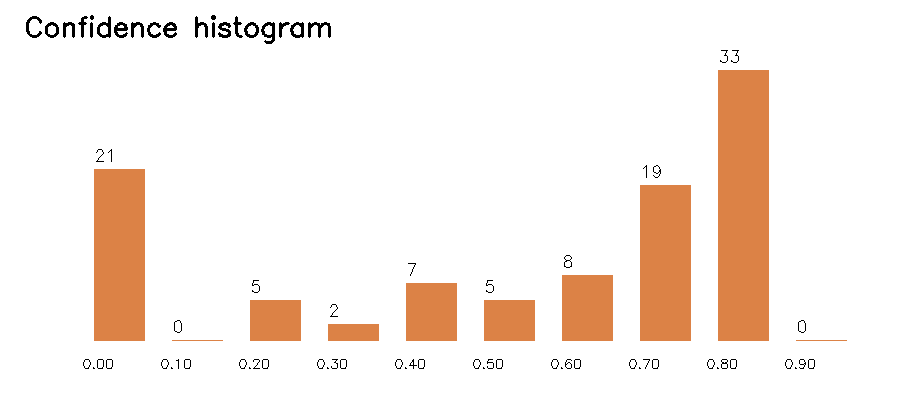

/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval/center_error_hist.png


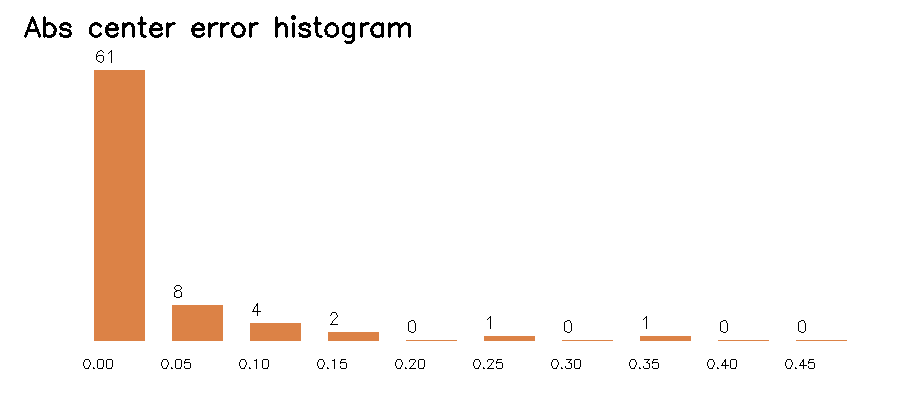

/home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/driver37_subset_eval/overlay_montage_first24.jpg


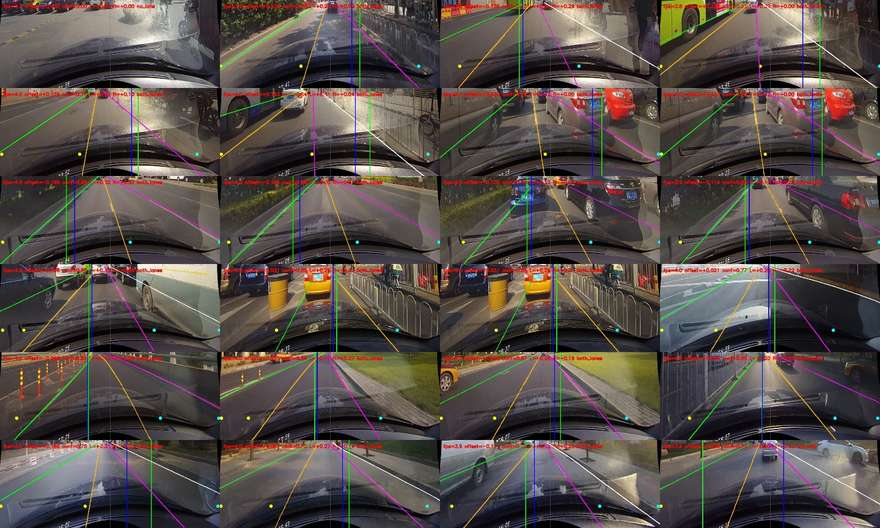

In [6]:
import json
from pathlib import Path

DRIVER37_EVAL_DIR = SANITY_DIR / 'driver37_subset_eval'
summary_path = DRIVER37_EVAL_DIR / 'summary.json'
print('summary_path:', summary_path)
assert summary_path.exists(), '아직 batch summary가 없음. 필요하면 02_lane_output_sanity_batch.py를 먼저 실행해야 함.'

summary = json.loads(summary_path.read_text(encoding='utf-8'))
print(json.dumps(summary, ensure_ascii=False, indent=2))

figure_paths = [
    DRIVER37_EVAL_DIR / 'reason_counts.png',
    DRIVER37_EVAL_DIR / 'confidence_hist.png',
    DRIVER37_EVAL_DIR / 'center_error_hist.png',
    DRIVER37_EVAL_DIR / 'overlay_montage_first24.jpg',
]
for fig in figure_paths:
    print(fig)
    if fig.exists():
        display(Image(filename=str(fig), width=900))

## 5. 카메라 새 프레임 저장

아래 셀은 카메라에서 새 프레임 1장을 캡처해서 저장할 때 사용한다.

카메라가 busy라고 나오면 다른 camera 셀 실행이 끝났는지 확인하거나 kernel을 restart한 뒤 다시 실행한다.

[0:42:16.019676691] [2212]  INFO Camera camera_manager.cpp:340 libcamera v0.6.0+rpt20251202
[0:42:16.028096358] [2239]  INFO RPI pisp.cpp:720 libpisp version 1.3.0
[0:42:16.030562524] [2239]  INFO IPAProxy ipa_proxy.cpp:180 Using tuning file /usr/share/libcamera/ipa/rpi/pisp/ov5647.json
[0:42:16.037335247] [2239]  INFO Camera camera_manager.cpp:223 Adding camera '/base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36' for pipeline handler rpi/pisp
[0:42:16.037350784] [2239]  INFO RPI pisp.cpp:1181 Registered camera /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 to CFE device /dev/media0 and ISP device /dev/media2 using PiSP variant BCM2712_C0
[0:42:16.040548876] [2212]  INFO Camera camera.cpp:1215 configuring streams: (0) 1296x972-RGB888/Rec709/Rec709/None/Full (1) 1296x972-GBRG_PISP_COMP1/RAW
[0:42:16.040635784] [2239]  INFO RPI pisp.cpp:1485 Sensor: /base/axi/pcie@1000120000/rp1/i2c@88000/ov5647@36 - Selected sensor format: 1296x972-SGBRG10_1X10/RAW - Selected CFE format: 1296x972-PC1g

fresh_path: /home/pi/AI_CAR/architecture_validation/lane_model/outputs/lane_output_sanity/02_fresh_camera_frame.jpg


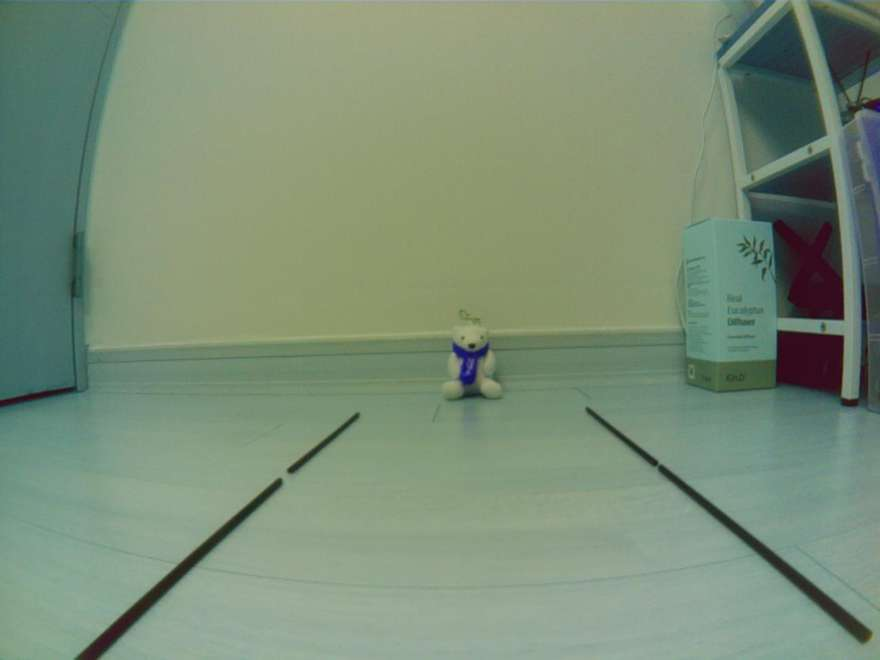

In [7]:
# 필요할 때만 실행.
# fresh_path를 만들고 싶으면 이 셀을 실행한 뒤 IMAGE_PATH를 fresh_path로 바꾸고 forward 셀을 다시 실행한다.

from picamera2 import Picamera2

fresh_path = SANITY_DIR / '02_fresh_camera_frame.jpg'
camera = Picamera2()
config = camera.create_video_configuration(main={'size': (1296, 972), 'format': 'RGB888'})
camera.configure(config)
camera.start()
time.sleep(1.0)
try:
    fresh_rgb = camera.capture_array()
finally:
    camera.stop()
    camera.close()

fresh_rgb = cv2.flip(fresh_rgb, -1)
PILImage.fromarray(fresh_rgb).save(fresh_path)
print('fresh_path:', fresh_path)
display(Image(filename=str(fresh_path), width=720))

## 6. 판단 메모

기록할 것:

```text
- 입력 이미지 종류: Pi sample / CULane example / CULane raw / map image
- output shape 정상 여부
- lane_count
- center_x / offset / confidence
- overlay가 실제 lane 위치와 맞는지
- no_lane이면 그 이유가 이미지 도메인 문제인지, decode 문제인지
```

이 FP32 결과가 이후 quantized ONNX와 비교할 기준선이다.

양자화 후에는 같은 이미지에 대해 아래를 비교한다.

```text
FP32 center_x vs INT8 center_x
FP32 lane_count vs INT8 lane_count
FP32 confidence vs INT8 confidence
FP32 overlay vs INT8 overlay
FP32 latency vs INT8 latency
```